In [1]:
setwd("F:/Data/杂/yin")

In [6]:
library(vegan)
library(ggplot2)
library(tidyverse)
library(agricolae)
library(reshape2)


Attaching package: 'reshape2'


The following object is masked from 'package:tidyr':

    smiths




## my_theme

In [3]:
my_theme = theme(axis.title = element_text(size = 20),
axis.text = element_text(size = 10),  legend.key.size = unit(40, "pt"),
                  legend.text = element_text(color = "black", size = 20),
                  legend.background = element_rect(fill = "white", color = "white"),
                  legend.title = element_text(size = 20),
                  legend.key = element_rect(fill = "white"))

## read data

In [4]:
asv_table = read.csv("asv_table.csv",row.names=1,header = T)
group = read.csv("group.csv")
asv_table = asv_table[,group$sample]
asv_tab.t = t(asv_table)


## alpha diversity

In [28]:
shannon = diversity(asv_tab.t, index = "shannon")
chao1 = estimateR(asv_tab.t)[2,]
richness = specnumber(asv_tab.t)
alpha = data.frame(richness,shannon,chao1)


## beta diversity

In [16]:
dist = as.matrix(vegdist(asv_tab.t, method = "bray" ))
pcoa = cmdscale(dist,  k = 2, eig = T, add = T)

In [ ]:
adonis = adonis2(asv_tab.t ~ group$group)
anosim = anosim(dist, group$group,permutations = 999)
adonis
anosim

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
group$group,2,2.0747341,0.7008805,17.57359,0.001
Residual,15,0.8854482,0.2991195,NA,NA
Total,17,2.9601823,1.0000000,NA,NA



Call:
anosim(x = dist, grouping = group$group, permutations = 999) 
Dissimilarity: user supplied square matrix 

ANOSIM statistic R: 0.7658 
      Significance: 0.001 

Permutation: free
Number of permutations: 999


In [31]:
alpha_beta = data.frame(richness,shannon,chao1,pcoa_site)

$statistics
   MSerror Df     Mean       CV t.value      LSD
  487.7111 15 113.2222 19.50517 2.13145 27.17664

$parameters
        test p.ajusted name.t ntr alpha
  Fisher-LSD      none  group   3  0.05

$means
       richness       std r       LCL      UCL Min Max    Q25   Q50    Q75
Middle 133.3333  4.760952 6 114.11655 152.5501 125 138 131.75 134.5 136.50
Mild   121.8333 21.994696 6 102.61655 141.0501 106 163 107.75 112.5 126.25
Severe  84.5000 30.930567 6  65.28321 103.7168  42 121  62.50  89.0 106.50

$comparison
NULL

$groups
       richness groups
Middle 133.3333      a
Mild   121.8333      a
Severe  84.5000      b

attr(,"class")
[1] "group"

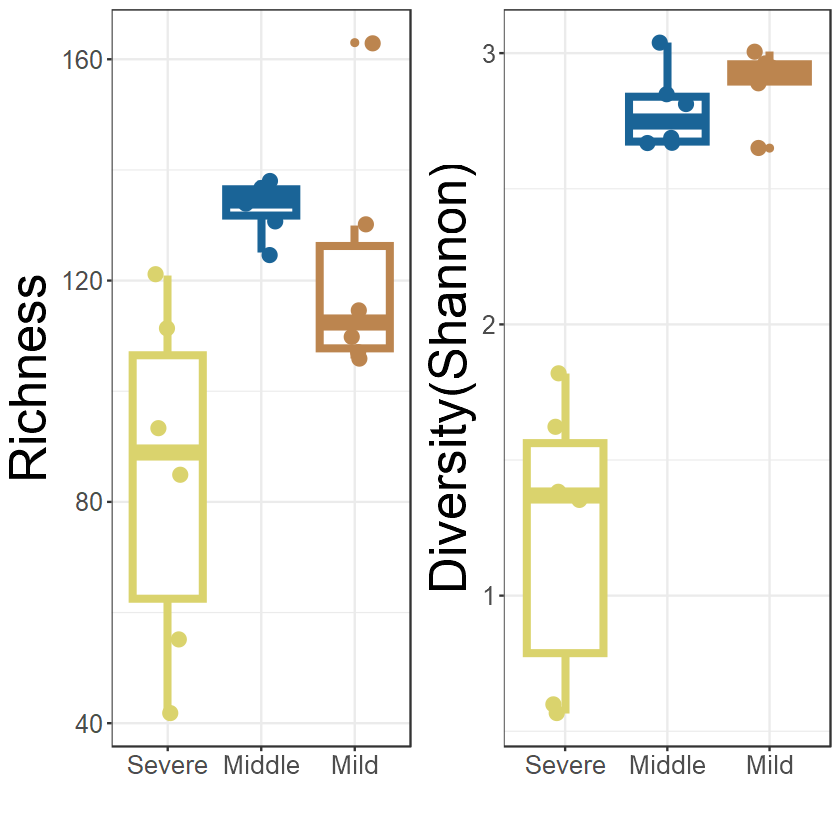

In [37]:
lsd_res = LSD.test(aov(richness ~ group,data = alpha_beta), "group", group = T)
lsd_res
lsd_res = LSD.test(aov(shannon ~ group,data = alpha_beta), "group", group = T)
alpha_beta$group = factor(alpha_beta$group,levels = c("Severe","Middle","Mild"))
p_richness = ggplot(alpha_beta, aes(x = group, y = richness)) +
    geom_boxplot(aes(color = group),linewidth = 1.7) +
    geom_jitter(aes(color = group),width = 0.2,size = 3.5) +
    labs(y = "Richness") +
    theme_bw() +
    xlab("") +
    my_theme +
    theme(legend.position = "none",
    axis.title = element_text(size = 30),
    axis.text = element_text(size = 15)) +
    scale_fill_manual(values = c("#DAD36D", "#1A6497", "#BC854F")) +
    scale_color_manual(values = c("#DAD36D", "#1A6497", "#BC854F"))

p_shannon = ggplot(alpha_beta, aes(x = group, y = shannon)) +
    geom_boxplot(aes(color = group),linewidth = 1.7) +
    geom_jitter(aes(color = group),width = 0.2,size = 3.5) +
    labs(y = "Diversity(Shannon)") +
    theme_bw() +
    xlab("") +
    my_theme +
    theme(legend.position = "none",
    axis.title = element_text(size = 30),
    axis.text = element_text(size = 15)) +
    scale_fill_manual(values = c("#DAD36D", "#1A6497", "#BC854F")) +
    scale_color_manual(values = c("#DAD36D", "#1A6497", "#BC854F"))


ggpubr::ggarrange(p_richness,p_shannon,ncol = 2,nrow = 1)

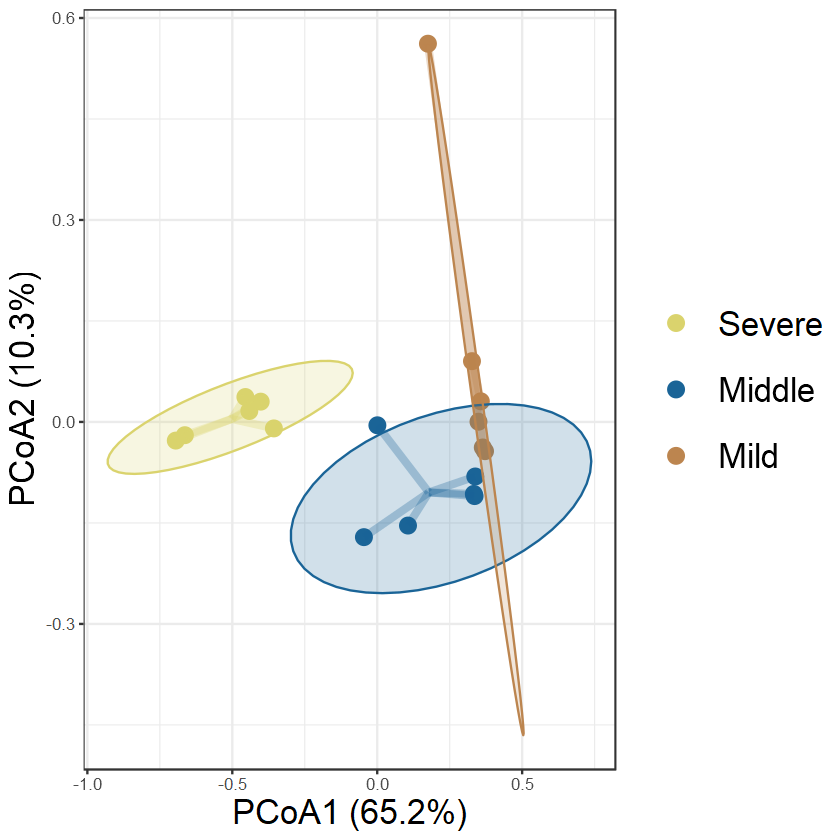

In [36]:
library(ggh4x)
p_pcoa = ggplot(alpha_beta, aes(PCoA1, PCoA2, color = group)) +
    geom_point(size = 4) +
    stat_centroid(aes(xend = PCoA1, yend = PCoA2, colour = group),geom = "segment",crop_other = F,
                  alpha=0.3,size = 1,show.legend = F,linewidth = 1.7) +
    stat_ellipse(geom = "polygon", aes(fill = group), alpha = 0.2, show.legend = FALSE, level = 0.95) +
    labs(x = paste("PCoA1 (", format(100 * pcoa$eig[1] / sum(pcoa$eig), digits = 3), "%)", sep = ""),
         y = paste("PCoA2 (", format(100 * pcoa$eig[2] / sum(pcoa$eig), digits = 3), "%)", sep = "")) +
         theme_bw() +
         my_theme +
    theme(legend.title = element_blank()) +
    scale_fill_manual(values = c("#DAD36D", "#1A6497", "#BC854F")) +
    scale_color_manual(values = c("#DAD36D", "#1A6497", "#BC854F"))
p_pcoa

### network analysis

In [2]:
library(ggplot2)
library(ggrepel)
library(SpiecEasi)
library(ggClusterNet)
library(phyloseq)
library(dplyr)
library(tidyverse)
library(Biostrings)
library(igraph)
library(sna)
library(patchwork)
library(ggpubr)
library(tidyfst)
library(pulsar)

Warning message:
"package 'ggplot2' was built under R version 4.2.3"

Attaching package: 'ggClusterNet'


The following object is masked from 'package:ggplot2':

    alpha


Warning message:
"package 'dplyr' was built under R version 4.2.3"

Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


── Attaching packages ─────────────────────────────────────── tidyverse 1.3.2 ──
✔ tibble  3.3.0     ✔ purrr   1.0.1
✔ tidyr   1.3.0     ✔ stringr 1.5.0
✔ readr   2.1.3     ✔ forcats 1.0.0
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ ggClusterNet::alpha() masks ggplot2::alpha()
✖ dplyr::filter()       masks stats::filter()
✖ dplyr::lag()          masks stats::lag()
Loading required package: BiocGenerics


Attaching package: 'BiocGenerics'


The following objects are masked from 'package:dplyr':

    combine, inters

#### Remove low-abundance ASVs

In [ ]:
asv_ab = read.csv("asv_abundance.csv",row.names=1,header = T)
mean_rel_abundance <- rowMeans(asv_ab) 
low_rel_abundance_otu <- rownames(asv_ab)[mean_rel_abundance < 0.0001]  
asv_ab_filtered <- asv_ab[!(rownames(asv_ab) %in% low_rel_abundance_otu), ] 
freq <- apply(asv_ab_filtered, 1, function(x) sum(x > 0)/length(x))
keep <- freq >= 1/5  
asv_ab_filt <- asv_ab_filtered[keep, ] 
write.csv(asv_ab_filt, 'asv_abundance_filt_fornetwork.csv') 

#### Construst the phyloseq object

In [5]:
otu_p = as.matrix(read.table("asv_filt_fornetwork.csv", header = TRUE, sep = ",", row.names = 1))
tax_p = as.matrix(read.table("tax.csv", header = TRUE, sep = ",", row.names = 1))
meta_p = read.delim("./metadata.tsv", row.names = 1)

OTU = otu_table(otu_p, taxa_are_rows = TRUE)
TAX = tax_table(tax_p)
META = sample_data(meta_p)
ps = phyloseq(OTU, TAX, META)

In [ ]:
tab.r = network.pip(ps=ps, N = 300, big = F, select_layout = F, layout_net = "model_maptree2",
    r.threshold = 0.7,p.threshold = 0.05,method = "sparcc",maxnode = 2, label = F, lab = "element",group = "Group", 
    fill = "Phylum",size = "igraph.degree", zipi = T, ram.net = T, clu_method = "cluster_fast_greedy",step = 100, R = 10, ncpus = 1)

In [ ]:
saveRDS(tab.r,"78asvs_network.pip.sparcc.rds")

In [7]:
tab.r = readRDS("78asvs_network.pip.sparcc.rds")
dat = tab.r[[2]]
cortab = dat$net.cor.matrix$cortab

In [11]:
for (i in 1:length(names(cortab))) {
  pst = ps %>%
    subset_samples.wt("Group",names(cortab)[i]) %>%
    subset_taxa.wt("OTU",colnames(cortab[[names(cortab)[i]]])) %>%
    filter_taxa(function(x) sum(x ) > 0, TRUE) %>%
    scale_micro("rela")
  
  dat.f = netproperties.sample(pst = pst,cor = cortab[[names(cortab)[i]]])
  head(dat.f)
  if (i == 1) {
    dat.f2 = dat.f
  }else{
    dat.f2 = rbind( dat.f2, dat.f)
  }
  
}

In [12]:
node = dat$net.cor.matrix$node
edge = dat$net.cor.matrix$edge
#write.csv(node,"node.csv")
#write.csv(edge,"edge.csv")

In [13]:
node$group = factor(node$group, levels = c("Severe","Middle","Mild"))
edge$group = factor(edge$group,levels = c("Severe","Middle","Mild"))

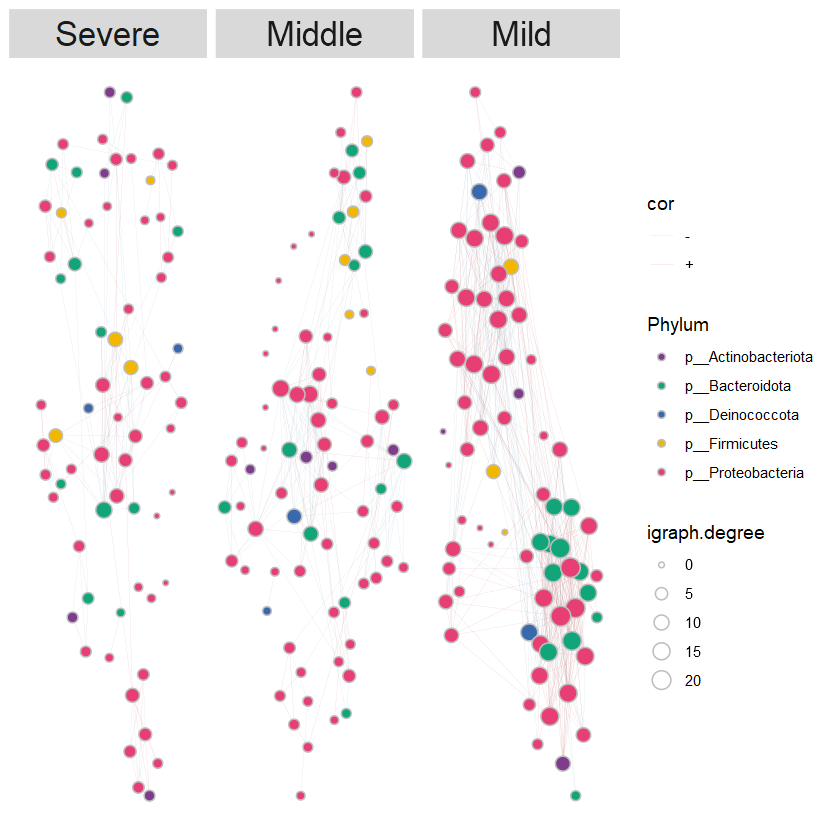

In [20]:
ggplot() + geom_segment(aes(x = X1, y = Y1, xend = X2, yend = Y2,color = cor
),
data = edge, size = 0.03,alpha = 0.5) +
  geom_point(aes(X1, X2,
                 fill = Phylum,
                 size = igraph.degree),
             pch = 21, data = node,color = "grey") +
  facet_wrap(.~ group,scales="free_y",nrow = 1) +
  # geom_text_repel(aes(X1, X2,label = elements),pch = 21, data = nodeG) +
  # geom_text(aes(X1, X2,label = elements),pch = 21, data = nodeG) +
  scale_colour_manual(values = c("#6D98B5","#bd4242")) +
  scale_fill_manual(values = c("#7F3C8D","#11A579","#3969AC","#F2B701","#E73F74","#80BA5A","#E68310","#008695","#CF1C90","#f97b72","#4b4b8f", "#bdb5d7", "#7356b1", "#c29e64", "#e36f85", "#003c75", "#5d4f57")) +
  scale_size(range = c(1, 5)) +
  scale_x_continuous(breaks = NULL) +
  scale_y_continuous(breaks = NULL) +
  theme(panel.background = element_blank(),
        plot.title = element_text(hjust = 0.5)
  ) +
  theme(axis.title.x = element_blank(),
        axis.title.y = element_blank()
  ) +
  theme(legend.background = element_rect(colour = NA)) +
  theme(panel.background = element_rect(fill = "white",  colour = NA)) +
  theme(panel.grid.minor = element_blank(), panel.grid.major = element_blank(),
        strip.text = element_text(size = 20))

In [25]:
lsdres = LSD.test(aov(igraph.degree~group,data = node),"group",group = T)
lsdres$group

,igraph.degree,groups
,<dbl>,<chr>
Mild,11.013333,a
Middle,4.282051,b
Severe,3.611940,b


In [23]:
lsdres = LSD.test(aov(igraph.closeness~group,data = node),"group",group = T)
lsdres$group

,igraph.closeness,groups
,<dbl>,<chr>
Mild,0.4055270,a
Severe,0.3071740,b
Middle,0.2710542,b


Warning message:
"Removed 7 rows containing missing values or values outside the scale range
(`geom_point()`)."


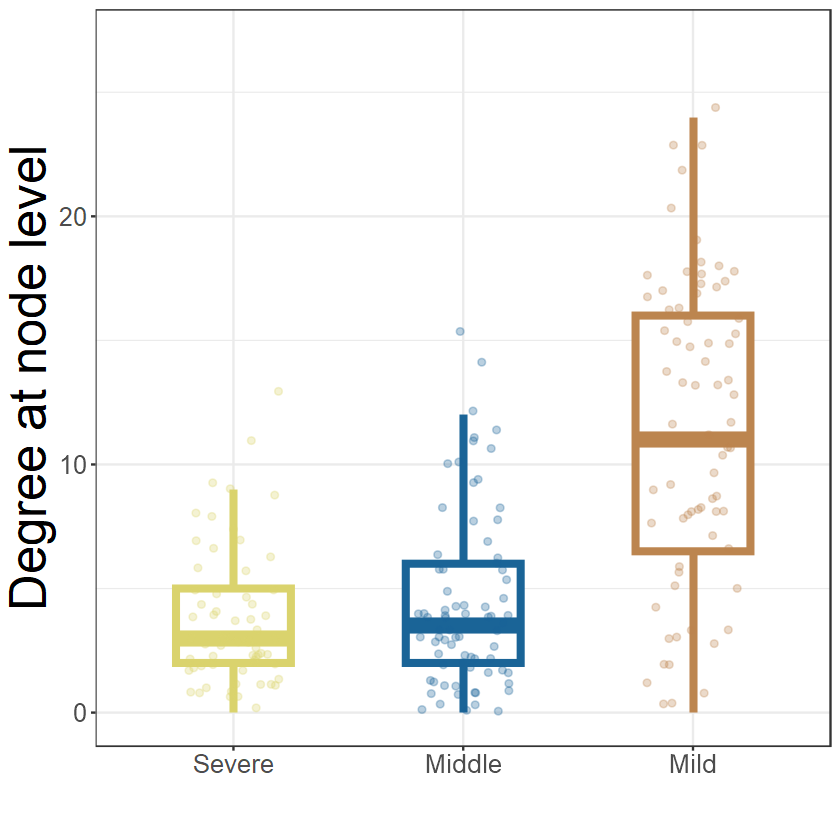

In [17]:
ggplot(node, aes(group, igraph.degree)) +
    geom_boxplot(aes(color = group),width = 0.5,fill = "white",outlier.shape = NA,linewidth = 1.7) +
    geom_jitter(aes(color = group),width = 0.2,size = 1.5,alpha = .3) +
    labs(y = "Degree at node level") +
    theme_bw() +
    xlab("") +
    my_theme +
    theme(legend.position = "none",
    axis.title = element_text(size = 30),
    axis.text = element_text(size = 15)) +
    scale_fill_manual(values = c("#DAD36D", "#1A6497", "#BC854F")) +
    scale_color_manual(values = c("#DAD36D", "#1A6497", "#BC854F")) +
    ylim(0,27) 

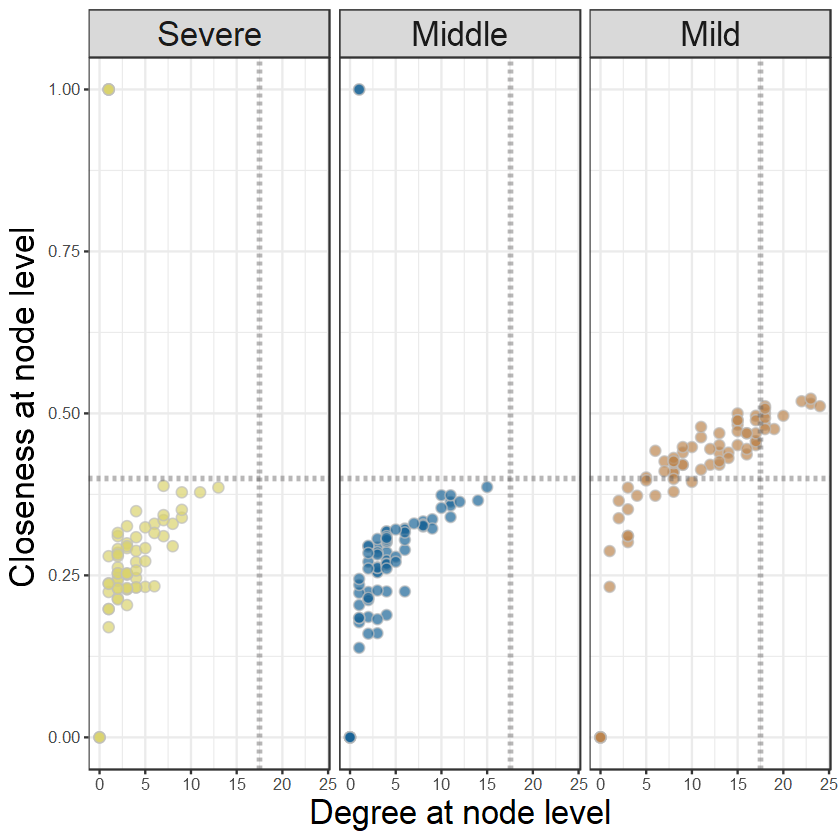

In [16]:
ggplot(node, aes(igraph.degree,igraph.closeness)) +
    geom_point(aes(fill = group),color = "grey",size = 2.5,alpha = .7,pch=21) +
    geom_hline(yintercept = 0.4,linetype = "dashed",color = "#67656576",linewidth = 1.2) +
    geom_vline(xintercept = 17.5,linetype = "dashed",color = "#67656576",linewidth = 1.2) +
    facet_wrap(.~group) +
    xlab("Degree at node level") +
    ylab("Closeness at node level") +
    theme_bw() +
    my_theme +
    theme(strip.text = element_text(size = 20)) +
    scale_fill_manual(values = c("#DAD36D", "#1A6497", "#BC854F")) +
    scale_color_manual(values = c("#DAD36D", "#1A6497", "#BC854F"))  +
    theme(legend.position = "none")

In [ ]:
asv_tab_m = asv_table %>% rownames_to_column(var = "ASV") %>% melt(variable.name = "sample") %>% left_join(group,by = "sample") 

Using ASV as id variables



#### Severe.vs.Middle

In [12]:
asv_tab_m1 = asv_tab_m %>% 
    subset(group != "Mild") 
asv_tab_m1$group = factor(asv_tab_m1$group,levels = c("Severe","Middle"))

sev.vs.middle = asv_tab_m1 %>%
    group_by(ASV) %>%
    group_modify(~{
        res = t.test(value ~ group, data = .x)
        tibble(
            "p.value" = res$p.value,
            foldchange = res$estimate[1]/res$estimate[2]
        )
    }) %>% mutate(significant = ifelse(p.value < 0.05, "yes", "no")) %>%
    mutate(enrichment = case_when(foldchange>1 & p.value <0.05 ~ "up", foldchange<1 & p.value <0.05 ~ "down", TRUE ~ "noise"), group = "Severe.vs.Mild")

#### Severe.vs.Mild

In [13]:
asv_tab_m2 = asv_tab_m %>% 
    subset(group != "Middle")
asv_tab_m2$group = factor(asv_tab_m2$group,levels = c("Severe","Mild"))

sev.vs.mild = asv_tab_m2 %>%
    group_by(ASV) %>%
    group_modify(~{
        res = t.test(value ~ group, data = .x)
        tibble(
            "p.value" = res$p.value,
            foldchange = res$estimate[1]/res$estimate[2]
        )
    }) %>% mutate(significant = ifelse(p.value < 0.05, "yes", "no")) %>%
    mutate(enrichment = case_when(foldchange>1 & p.value <0.05 ~ "up", foldchange<1 & p.value <0.05 ~ "down", TRUE ~ "noise"), group = "Severe vs. Mild")


#### Middle.vs.Mild

In [14]:
asv_tab_m3 = asv_tab_m %>% 
    subset(group != "Severe") 
asv_tab_m3$group = factor(asv_tab_m3$group,levels = c("Middle","Mild"))

middle.vs.mild = asv_tab_m3 %>%
    group_by(ASV) %>%
    group_modify(~{
        res = t.test(value ~ group, data = .x,alternative = "less")
        tibble(
            "p.value" = res$p.value,
            foldchange = res$estimate[1]/res$estimate[2]
        )
    }) %>% mutate(significant = ifelse(p.value < 0.05, "yes", "no")) %>%
    mutate(enrichment = case_when(foldchange>1 & p.value <0.05 ~ "up", foldchange<1 & p.value <0.05 ~ "down", TRUE ~ "noise"), group = "Middle vs. Mild")


In [ ]:
tax = read.csv("tax.csv") %>% select(ASV,Phylum)
t.test_res = rbind(sev.vs.mild,middle.vs.mild,sev.vs.middle) %>% na.omit%>% left_join(tax, by = "ASV")

In [ ]:
t.test_res = factor(t.test_res$group, levels = c("Middle vs. Mild","Severe vs. Middle","Severe vs. Mild"))
t.test_res$enrichment = factor(t.test_res$enrichment, levels = c("up","down","noise"))

In [ ]:
ggplot() +
    geom_point(data = subset(t.test_res,significant == "no"),aes(x = group, y = -log10(p.value)),size = 2,color = "grey") +
    geom_vline(xintercept = -log10(0.05),linetype = "dashed",color = "#67656576",linewidth = 1.2) +
    geom_point(data = subset(t.test_res,significant == "yes"),aes(x = group, y = -log10(p.value),color = Phylum, shape = enrichment)) +
    #scale_fill_manual(values = c("#e69f00", "#2449a2", "#8abfb9","#007554")) +
    scale_color_manual(values = c("#e69f00", "#2449a2", "#8abfb9","#007554")) +
    scale_shape_manual(values = c(2,6)) +
    theme_bw() +
    my_theme +
    theme(legend.position = "none",
    axis.title = element_text(size = 30),
    axis.text = element_text(size = 15)) +
    labs(x = "",y = "-log10(p-value)")

In [ ]:
library(ggtern)


ggtern(data = tern, aes(x = Severe, y = Middle, z = Mild)) +
    geom_point(aes(color = Phylum, size = Abundance)) +
    theme_bw() +
    my_theme